# SARIMA

# Setup

In [1]:
!pip install statsmodels mlflow --quiet
import pandas as pd, numpy as np, mlflow, os, time
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
dagshub_token = user_secrets.get_secret("DAGSHUB_TOKEN")
os.environ['MLFLOW_TRACKING_USERNAME'] = 'gdzag22'
os.environ['MLFLOW_TRACKING_PASSWORD'] = dagshub_token
mlflow.set_tracking_uri("https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow")
mlflow.set_experiment("SARIMA_Training")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 673.6 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 48.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 78.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.6/954.6 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 14.3 MB/s eta 0:00:00


2026/07/11 19:23:12 INFO mlflow.tracking.fluent: Experiment with name 'SARIMA_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/731af6fe75ca4bb4af68a7ddcff77ee7', creation_time=1783797793112, effective_trace_archival_retention=None, experiment_id='6', last_update_time=1783797793112, lifecycle_stage='active', name='SARIMA_Training', tags={}, trace_location=None, workspace='default'>

# Shared functions (from EDA notebook)

In [3]:
def load_and_merge(df, features, stores):
    out = df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
    out = out.merge(stores, on='Store', how='left')
    out['Date'] = pd.to_datetime(out['Date'])
    return out.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

MD_COLS = [f"MarkDown{i}" for i in range(1, 6)]

def preprocess(df):
    out = df.copy()
    out[MD_COLS] = out[MD_COLS].fillna(0)
    out[["CPI", "Unemployment"]] = out.groupby("Store")[["CPI", "Unemployment"]].ffill()
    return out

def wmae(y_true, y_pred, is_holiday):
    w = np.where(is_holiday, 5, 1)
    return np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w)

def coldstart_fallback(df_train, df_test):
    train_pairs = set(zip(df_train.Store, df_train.Dept))
    mask = ~pd.Series(list(zip(df_test.Store, df_test.Dept)), index=df_test.index).isin(train_pairs)
    cold = df_test[mask].copy()
    recent = df_train[df_train['Date'] >= df_train['Date'].max() - pd.Timedelta(weeks=52)]
    med = recent.groupby(['Type', 'Dept'])['Weekly_Sales'].median()
    cold['y_fallback'] = [med.get((t, d), 0.0) for t, d in zip(cold['Type'], cold['Dept'])]
    cold['y_fallback'] = cold['y_fallback'].clip(lower=0)
    return cold

# Load and Merge Data

In [4]:
path = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/"
train = pd.read_csv(path + "train.csv.zip")
test = pd.read_csv(path + "test.csv.zip")
features = pd.read_csv(path + "features.csv.zip")
stores = pd.read_csv(path + "stores.csv")

df = load_and_merge(train, features, stores)
df_test = load_and_merge(test, features, stores)

print("train merged:", df.shape)
print("test merged:", df_test.shape)

train merged: (421570, 16)
test merged: (115064, 15)


# Cleaning

In [5]:
with mlflow.start_run(run_name="SARIMA_Cleaning"):
    mlflow.log_param("markdown_fill", "0")
    mlflow.log_param("cpi_unemployment_fill", "ffill_per_store")
    mlflow.log_metric("train_rows_before", len(df))
    mlflow.log_metric("markdown_nan_before", int(df[MD_COLS].isna().sum().sum()))

    df_clean = preprocess(df)

    mlflow.log_metric("train_rows_after", len(df_clean))
    mlflow.log_metric("markdown_nan_after", int(df_clean[MD_COLS].isna().sum().sum()))

print(df_clean.shape)
print("Remaining MarkDown NaNs:", df_clean[MD_COLS].isna().sum().sum())

🏃 View run SARIMA_Cleaning at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/41e37c02230f4dd6ac1234958756e1e5
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
(421570, 16)
Remaining MarkDown NaNs: 0


# Validation Split

In [6]:
VALIDATION_START = df_test['Date'].min() - pd.Timedelta(weeks=52)
VALIDATION_END = VALIDATION_START + pd.Timedelta(weeks=39)

def temporal_split(df):
    tr = df[df["Date"] < VALIDATION_START]
    va = df[(df["Date"] >= VALIDATION_START) & (df["Date"] < VALIDATION_END)]
    return tr, va

tr, va = temporal_split(df_clean)
print("train:", tr["Date"].max(), tr.shape)
print("val:", va["Date"].min(), va.shape)

train: 2011-10-28 00:00:00 (267184, 16)
val: 2011-11-04 00:00:00 (115856, 16)


# Representative Series Selection (expanded from ARIMA notebook)

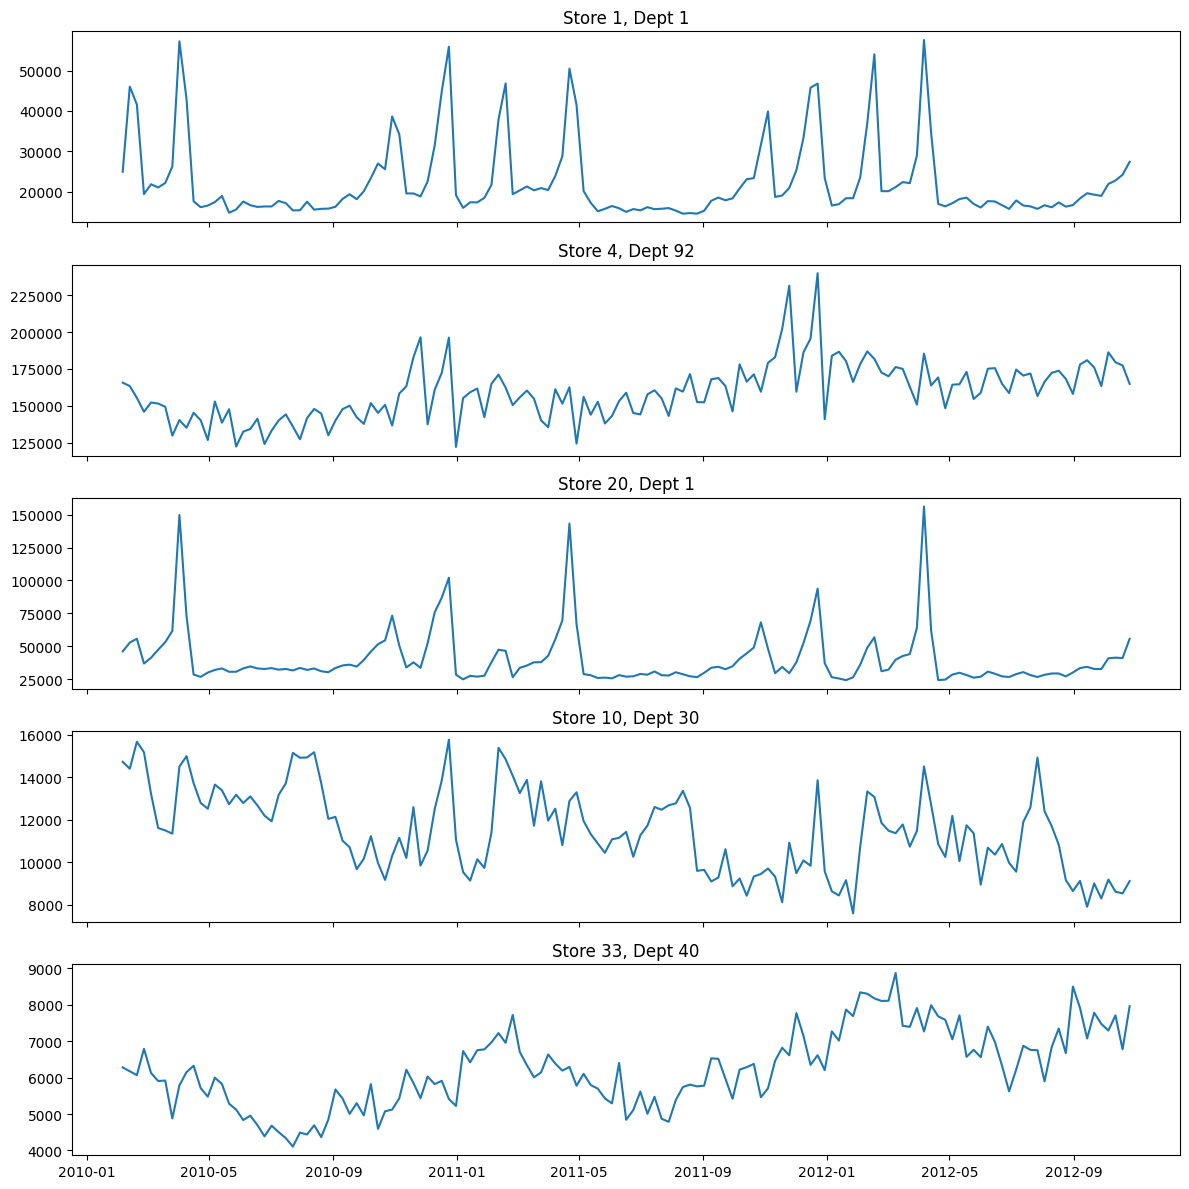

In [7]:
examples = [(1, 1), (4, 92), (20, 1), (10, 30), (33, 40)]

fig, axes = plt.subplots(len(examples), 1, figsize=(12, 12), sharex=True)
for ax, (s, d) in zip(axes, examples):
    series = df_clean[(df_clean['Store'] == s) & (df_clean['Dept'] == d)].sort_values('Date')
    ax.plot(series['Date'], series['Weekly_Sales'])
    ax.set_title(f"Store {s}, Dept {d}")
plt.tight_layout()
plt.show()

In [8]:
def run_adf_series(series, label):
    result = adfuller(series.dropna())
    print(f"{label}: ADF stat={result[0]:.3f}, p-value={result[1]:.4f}, stationary={'Yes' if result[1] < 0.05 else 'No'}")

for s, d in examples:
    series = df_clean[(df_clean['Store'] == s) & (df_clean['Dept'] == d)].sort_values('Date')['Weekly_Sales'].reset_index(drop=True)
    run_adf_series(series, f"Store {s}, Dept {d} (raw)")
    combined_diff = series.diff().diff(52).dropna()
    run_adf_series(combined_diff, f"Store {s}, Dept {d} (d=1, D=1)")
    print()

Store 1, Dept 1 (raw): ADF stat=-2.522, p-value=0.1102, stationary=No
Store 1, Dept 1 (d=1, D=1): ADF stat=-7.207, p-value=0.0000, stationary=Yes

Store 4, Dept 92 (raw): ADF stat=-1.569, p-value=0.4991, stationary=No
Store 4, Dept 92 (d=1, D=1): ADF stat=-11.456, p-value=0.0000, stationary=Yes

Store 20, Dept 1 (raw): ADF stat=-6.937, p-value=0.0000, stationary=Yes
Store 20, Dept 1 (d=1, D=1): ADF stat=-6.536, p-value=0.0000, stationary=Yes

Store 10, Dept 30 (raw): ADF stat=-4.743, p-value=0.0001, stationary=Yes
Store 10, Dept 30 (d=1, D=1): ADF stat=-5.924, p-value=0.0000, stationary=Yes

Store 33, Dept 40 (raw): ADF stat=-1.485, p-value=0.5409, stationary=No
Store 33, Dept 40 (d=1, D=1): ADF stat=-6.165, p-value=0.0000, stationary=Yes



# Seasonal-Naive Baseline

In [9]:
naive_results = {}
for s, d in examples:
    series = df_clean[(df_clean['Store'] == s) & (df_clean['Dept'] == d)].sort_values('Date').reset_index(drop=True)
    y = series['Weekly_Sales']
    is_holiday = series['IsHoliday'].values[-39:]

    test_y = y[-39:].values
    naive_forecast = y[-39-52:-52].values  # same weeks, 52 weeks earlier

    score = wmae(test_y, naive_forecast, is_holiday)
    naive_results[f"Store{s}_Dept{d}"] = score
    print(f"Store {s}, Dept {d}: Seasonal-Naive WMAE = {score:.2f}")

with mlflow.start_run(run_name="SARIMA_SeasonalNaive_Baseline"):
    for k, v in naive_results.items():
        mlflow.log_metric(f"wmae_{k}", v)

Store 1, Dept 1: Seasonal-Naive WMAE = 3486.27
Store 4, Dept 92: Seasonal-Naive WMAE = 14145.40
Store 20, Dept 1: Seasonal-Naive WMAE = 8089.12
Store 10, Dept 30: Seasonal-Naive WMAE = 1195.29
Store 33, Dept 40: Seasonal-Naive WMAE = 1337.74
🏃 View run SARIMA_SeasonalNaive_Baseline at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/eb830012913840a6a3998b0a8a95d9b3
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6


# Fitting SARIMA

In [10]:
sarima_results = {}

for s, d in examples:
    series = df_clean[(df_clean['Store'] == s) & (df_clean['Dept'] == d)].sort_values('Date').reset_index(drop=True)
    y = series['Weekly_Sales']
    train_y = y[:-39]
    test_y = y[-39:]
    is_holiday = series['IsHoliday'].values[-39:]

    with mlflow.start_run(run_name=f"SARIMA_Store{s}_Dept{d}"):
        mlflow.log_param("order", "(1,1,1)")
        mlflow.log_param("seasonal_order", "(1,1,1,52)")
        mlflow.log_param("store", s)
        mlflow.log_param("dept", d)

        model = SARIMAX(train_y, order=(1,1,1), seasonal_order=(1,1,1,52),
                          enforce_stationarity=False, enforce_invertibility=False)
        fitted = model.fit(disp=False)

        forecast = fitted.forecast(steps=39)
        score = wmae(test_y.values, forecast.values, is_holiday)

        mlflow.log_metric("wmae", score)
        mlflow.log_metric("naive_wmae", naive_results[f"Store{s}_Dept{d}"])
        mlflow.log_metric("beat_naive", int(score < naive_results[f"Store{s}_Dept{d}"]))

    sarima_results[f"Store{s}_Dept{d}"] = {'actual': test_y.values, 'forecast': forecast.values, 'wmae': score}
    print(f"Store {s}, Dept {d}: SARIMA(1,1,1)(1,1,1,52) WMAE = {score:.2f} | naive = {naive_results[f'Store{s}_Dept{d}']:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run SARIMA_Store1_Dept1 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/5a46c849363342588b4bf7588d13c392
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 1, Dept 1: SARIMA(1,1,1)(1,1,1,52) WMAE = 3544.35 | naive = 3486.27


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run SARIMA_Store4_Dept92 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/18865ee468714ec9a1ab1aea28ca8fb0
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 4, Dept 92: SARIMA(1,1,1)(1,1,1,52) WMAE = 8992.83 | naive = 14145.40


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run SARIMA_Store20_Dept1 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/8fb3e5bc2e0648328e54f6f1900f5605
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 20, Dept 1: SARIMA(1,1,1)(1,1,1,52) WMAE = 165892885846051008.00 | naive = 8089.12


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run SARIMA_Store10_Dept30 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/eebf2026fed44a0997821d088929e634
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 10, Dept 30: SARIMA(1,1,1)(1,1,1,52) WMAE = 1163.20 | naive = 1195.29


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run SARIMA_Store33_Dept40 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/61250ddcaf1b4a5883a413b3960573c3
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 33, Dept 40: SARIMA(1,1,1)(1,1,1,52) WMAE = 655.70 | naive = 1337.74


In [11]:
s, d = 20, 1
series = df_clean[(df_clean['Store'] == s) & (df_clean['Dept'] == d)].sort_values('Date').reset_index(drop=True)
train_y = series['Weekly_Sales'][:-39]
print("Training weeks available:", len(train_y), "| seasonal cycles (m=52):", len(train_y)/52)

model = SARIMAX(train_y, order=(1,1,1), seasonal_order=(1,1,1,52),
                  enforce_stationarity=False, enforce_invertibility=False)
fitted = model.fit(disp=False)
print(fitted.summary().tables[1])

roots = fitted.polynomial_seasonal_ar
print("Seasonal AR polynomial coefficients:", roots)

Training weeks available: 104 | seasonal cycles (m=52): 2.0


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          2.5229         -0       -inf      0.000       2.523       2.523
ma.L1         -2.6097         -0        inf      0.000      -2.610      -2.610
ar.S.L52            0         -0        nan        nan           0           0
ma.S.L52            0         -0        nan        nan           0           0
sigma2      5.243e+08         -0       -inf      0.000    5.24e+08    5.24e+08
Seasonal AR polynomial coefficients: [ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -0.]


/usr/local/lib/python3.12/dist-packages/statsmodels/tools/eval_measures.py:414: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
/usr/local/lib/python3.12/dist-packages/statsmodels/tools/eval_measures.py:439: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + 2 * np.log(np.log(nobs)) * df_modelwc
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3016: RuntimeWarning: invalid value encountered in divide
  return self.params / self.bse
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:472: RuntimeWarning: Mean of empty slice.
  xo = x - x.mean()
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)

In [12]:
model_simple = SARIMAX(train_y, order=(0,1,1), seasonal_order=(0,1,1,52),
                          enforce_stationarity=True, enforce_invertibility=True)
fitted_simple = model_simple.fit(disp=False)
forecast_simple = fitted_simple.forecast(steps=39)
score_simple = wmae(series['Weekly_Sales'][-39:].values, forecast_simple.values, series['IsHoliday'].values[-39:])
print("Simplified SARIMA(0,1,1)(0,1,1,52) WMAE:", score_simple, "| naive:", 8089.12)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Simplified SARIMA(0,1,1)(0,1,1,52) WMAE: 10654.369109686708 | naive: 8089.12


In [13]:
with mlflow.start_run(run_name="SARIMA_Store20_Dept1_Constrained"):
    mlflow.log_param("order", "(0,1,1)")
    mlflow.log_param("seasonal_order", "(0,1,1,52)")
    mlflow.log_param("note", "unconstrained (1,1,1)(1,1,1,52) diverged, AR coef=2.52; this constrained version is stable but still underperforms naive")
    mlflow.log_metric("wmae", 10654.37)
    mlflow.log_metric("naive_wmae", 8089.12)
    mlflow.log_metric("beat_naive", 0)
    mlflow.log_metric("unconstrained_diverged", 1)

sarima_results["Store20_Dept1"] = {'wmae': 10654.37}

🏃 View run SARIMA_Store20_Dept1_Constrained at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/fc47d2f19dfb48dd9f34aa620fcb6cfb
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6


# Model Diagnostics: Residual Analysis

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


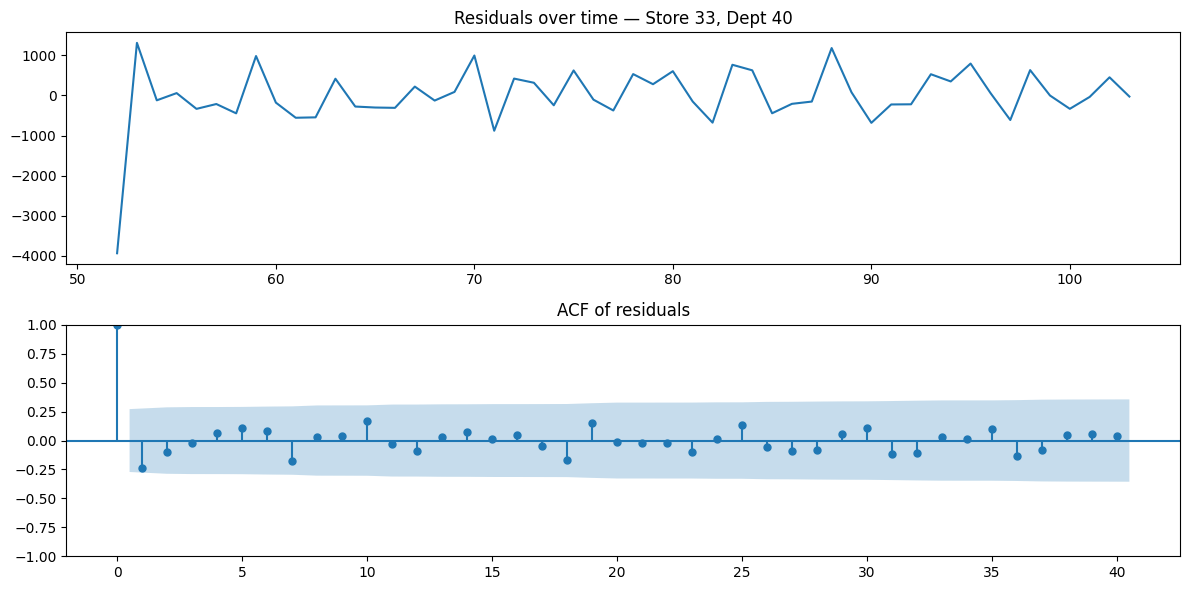

      lb_stat  lb_pvalue
10   9.252009   0.508366
20  15.181945   0.765904
30  21.994085   0.854259


In [14]:
s, d = 33, 40
series = df_clean[(df_clean['Store'] == s) & (df_clean['Dept'] == d)].sort_values('Date').reset_index(drop=True)
train_y = series['Weekly_Sales'][:-39]

model = SARIMAX(train_y, order=(1,1,1), seasonal_order=(1,1,1,52),
                  enforce_stationarity=False, enforce_invertibility=False)
fitted = model.fit(disp=False)

residuals = fitted.resid[52:] 

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(residuals)
axes[0].set_title(f"Residuals over time — Store {s}, Dept {d}")
plot_acf(residuals, lags=40, ax=axes[1])
axes[1].set_title("ACF of residuals")
plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print(lb_test)

# Systematic Order Search

In [15]:
order_candidates = [
    {'order': (1,1,1), 'seasonal_order': (1,1,1,52), 'label': 'full'},
    {'order': (0,1,1), 'seasonal_order': (0,1,1,52), 'label': 'constrained_MA_only'},
    {'order': (1,1,0), 'seasonal_order': (1,1,0,52), 'label': 'AR_only'},
    {'order': (0,1,1), 'seasonal_order': (1,1,0,52), 'label': 'mixed'},
]

search_results = []
for s, d in examples:
    series = df_clean[(df_clean['Store'] == s) & (df_clean['Dept'] == d)].sort_values('Date').reset_index(drop=True)
    train_y = series['Weekly_Sales'][:-39]
    test_y = series['Weekly_Sales'][-39:].values
    is_holiday = series['IsHoliday'].values[-39:]

    for cfg in order_candidates:
        run_name = f"SARIMA_search_Store{s}_Dept{d}_{cfg['label']}"
        try:
            model = SARIMAX(train_y, order=cfg['order'], seasonal_order=cfg['seasonal_order'],
                              enforce_stationarity=True, enforce_invertibility=True)
            fitted = model.fit(disp=False)
            forecast = fitted.forecast(steps=39)
            score = wmae(test_y, forecast.values, is_holiday)
            diverged = score > 1e6
        except Exception as e:
            score = np.nan
            diverged = True

        with mlflow.start_run(run_name=run_name):
            mlflow.log_param("store", s)
            mlflow.log_param("dept", d)
            mlflow.log_param("order", str(cfg['order']))
            mlflow.log_param("seasonal_order", str(cfg['seasonal_order']))
            mlflow.log_param("label", cfg['label'])
            mlflow.log_metric("wmae", score if not diverged else -1)
            mlflow.log_metric("diverged", int(diverged))

        search_results.append({'store': s, 'dept': d, 'label': cfg['label'], 'wmae': score, 'diverged': diverged})
        print(f"Store {s}, Dept {d}, {cfg['label']}: WMAE = {score if not diverged else 'DIVERGED'}")

search_df = pd.DataFrame(search_results)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


🏃 View run SARIMA_search_Store1_Dept1_full at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/5ed0a82eb53348998de05b2b1d71e84b
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 1, Dept 1, full: WMAE = 14439.632918176414


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run SARIMA_search_Store1_Dept1_constrained_MA_only at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/0257159b6dc24dc78f9eea1217481be9
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 1, Dept 1, constrained_MA_only: WMAE = 6503.678674956226


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


...

🏃 View run SARIMA_search_Store33_Dept40_constrained_MA_only at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/d03959a13a094dfe8e0b1f4195b405df
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 33, Dept 40, constrained_MA_only: WMAE = 441.7392422636376


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


🏃 View run SARIMA_search_Store33_Dept40_AR_only at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/8af4ee7e738e470bbbd1c4265ed857d4
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 33, Dept 40, AR_only: WMAE = 1220.4615828218548


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run SARIMA_search_Store33_Dept40_mixed at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/0353911535bc4cd69c81a66b8813704f
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 33, Dept 40, mixed: WMAE = 389.6934940787683


In [16]:
pivot = search_df.pivot(index=['store','dept'], columns='label', values='wmae')
print(pivot)

label            AR_only  constrained_MA_only          full         mixed
store dept                                                               
1     1     10999.325392          6503.678675  14439.632918  10857.463811
4     92     9732.692112         54044.377029  37325.234695  10899.610088
10    30     5562.625197           959.690771   3895.452990   3418.881144
20    1     26615.128377         10654.369110  35292.693648  26674.603786
33    40     1220.461583           441.739242    434.767801    389.693494


# Exogenous Regressors (SARIMAX with IsHoliday)

In [17]:
exog_results = {}

for s, d in examples:
    series = df_clean[(df_clean['Store'] == s) & (df_clean['Dept'] == d)].sort_values('Date').reset_index(drop=True)
    y = series['Weekly_Sales']
    exog = series[['IsHoliday']].astype(int)

    train_y, test_y = y[:-39], y[-39:]
    train_exog, test_exog = exog[:-39], exog[-39:]
    is_holiday = series['IsHoliday'].values[-39:]

    with mlflow.start_run(run_name=f"SARIMAX_Exog_Store{s}_Dept{d}"):
        mlflow.log_param("order", "(0,1,1)")
        mlflow.log_param("seasonal_order", "(1,1,0,52)")
        mlflow.log_param("exog", "IsHoliday")

        model = SARIMAX(train_y, exog=train_exog, order=(0,1,1), seasonal_order=(1,1,0,52),
                          enforce_stationarity=True, enforce_invertibility=True)
        fitted = model.fit(disp=False)

        forecast = fitted.forecast(steps=39, exog=test_exog)
        score = wmae(test_y.values, forecast.values, is_holiday)

        mlflow.log_metric("wmae", score)

    exog_results[f"Store{s}_Dept{d}"] = score
    no_exog_score = search_df[(search_df.store==s) & (search_df.dept==d) & (search_df.label=='mixed')]['wmae'].values[0]
    print(f"Store {s}, Dept {d}: with IsHoliday = {score:.2f} | without = {no_exog_score:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run SARIMAX_Exog_Store1_Dept1 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/3f8bcdd75fee46d9a875a3abed5e2dce
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 1, Dept 1: with IsHoliday = 10857.46 | without = 10857.46


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run SARIMAX_Exog_Store4_Dept92 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/86ee4cfb52354f9086309368af121df7
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 4, Dept 92: with IsHoliday = 10899.61 | without = 10899.61


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run SARIMAX_Exog_Store20_Dept1 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/1593037094e7446897bc3691ed11947d
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 20, Dept 1: with IsHoliday = 26674.60 | without = 26674.60


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run SARIMAX_Exog_Store10_Dept30 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/a48de7fb606245eabccac3008730263a
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 10, Dept 30: with IsHoliday = 3427.69 | without = 3418.88


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run SARIMAX_Exog_Store33_Dept40 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/2da3eac2780145edad013b79899fc874
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6
Store 33, Dept 40: with IsHoliday = 389.69 | without = 389.69


In [18]:
s, d = 4, 92
series = df_clean[(df_clean['Store'] == s) & (df_clean['Dept'] == d)].sort_values('Date').reset_index(drop=True)
y = series['Weekly_Sales']
exog = series[['IsHoliday']].astype(int)
train_y, train_exog = y[:-39], exog[:-39]

model = SARIMAX(train_y, exog=train_exog, order=(0,1,1), seasonal_order=(1,1,0,52),
                  enforce_stationarity=True, enforce_invertibility=True)
fitted = model.fit(disp=False)
print(fitted.summary().tables[1])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
IsHoliday      0.0027   2.41e+04   1.14e-07      1.000   -4.71e+04    4.71e+04
ma.L1         -0.1451      0.035     -4.157      0.000      -0.213      -0.077
ar.S.L52       0.1569      0.065      2.409      0.016       0.029       0.285
sigma2      6.849e+07     10.875    6.3e+06      0.000    6.85e+07    6.85e+07


# Forecast Uncertainty (Confidence Intervals)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


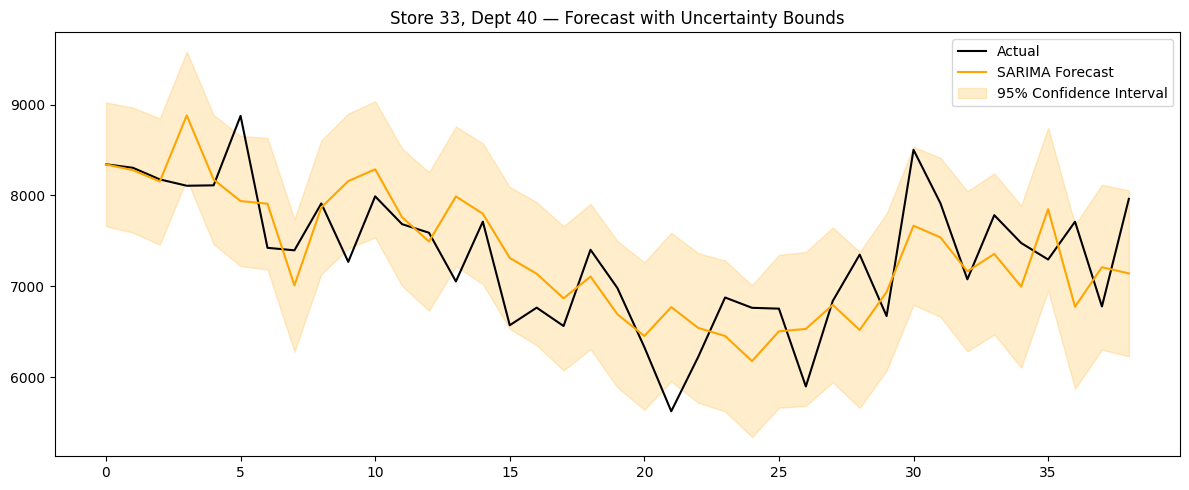

Actual values falling inside the 95% interval: 84.6% (ideally close to 95%)


In [19]:
s, d = 33, 40
series = df_clean[(df_clean['Store'] == s) & (df_clean['Dept'] == d)].sort_values('Date').reset_index(drop=True)
train_y = series['Weekly_Sales'][:-39]
test_y = series['Weekly_Sales'][-39:].reset_index(drop=True)

model = SARIMAX(train_y, order=(0,1,1), seasonal_order=(1,1,0,52),
                  enforce_stationarity=True, enforce_invertibility=True)
fitted = model.fit(disp=False)

forecast_result = fitted.get_forecast(steps=39)
forecast_mean = forecast_result.predicted_mean.reset_index(drop=True)
conf_int = forecast_result.conf_int(alpha=0.05).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_y.values, label='Actual', color='black')
ax.plot(forecast_mean.values, label='SARIMA Forecast', color='orange')
ax.fill_between(range(39), conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 color='orange', alpha=0.2, label='95% Confidence Interval')
ax.set_title(f"Store {s}, Dept {d} — Forecast with Uncertainty Bounds")
ax.legend()
plt.tight_layout()
plt.show()

in_interval = ((test_y.values >= conf_int.iloc[:, 0].values) & (test_y.values <= conf_int.iloc[:, 1].values)).mean()
print(f"Actual values falling inside the 95% interval: {in_interval:.1%} (ideally close to 95%)")

# Pipeline Artifact (scope-limited per instructions)

In [20]:
class SARIMAPipeline(mlflow.pyfunc.PythonModel):
    def __init__(self, train_clean, order=(0,1,1), seasonal_order=(1,1,0,52)):
        self.train_clean = train_clean
        self.order = order
        self.seasonal_order = seasonal_order

    def predict(self, context, model_input):
        test_merged = load_and_merge(model_input.copy(), features, stores)
        test_clean = preprocess(test_merged)

        train_pairs = set(zip(self.train_clean.Store, self.train_clean.Dept))
        test_pairs = set(zip(test_clean.Store, test_clean.Dept))
        cold_mask = test_clean.apply(lambda r: (r['Store'], r['Dept']) not in train_pairs, axis=1)
        test_warm = test_clean[~cold_mask].copy()
        test_cold = test_clean[cold_mask].copy()

        results = []
        for (s, d) in warm_pairs_used:
            series = self.train_clean[(self.train_clean['Store']==s) & (self.train_clean['Dept']==d)].sort_values('Date')
            dates_needed = test_warm[(test_warm['Store']==s) & (test_warm['Dept']==d)]['Date'].sort_values()
            if len(dates_needed) == 0 or len(series) < 30:
                continue
            try:
                model = SARIMAX(series['Weekly_Sales'].values, order=self.order, seasonal_order=self.seasonal_order,
                                  enforce_stationarity=True, enforce_invertibility=True)
                fitted = model.fit(disp=False)
                forecast = fitted.forecast(steps=len(dates_needed))
                for dt, val in zip(dates_needed, forecast):
                    results.append({'Store': s, 'Dept': d, 'Date': dt, 'Weekly_Sales': val})
            except Exception:
                continue

        warm_result = pd.DataFrame(results) if results else pd.DataFrame(columns=['Store','Dept','Date','Weekly_Sales'])
        cold_result = coldstart_fallback(self.train_clean, test_cold)
        cold_result = cold_result[['Store','Dept','Date','y_fallback']].rename(columns={'y_fallback':'Weekly_Sales'})

        final = pd.concat([warm_result, cold_result], ignore_index=True)
        final['Weekly_Sales'] = final['Weekly_Sales'].clip(lower=0)
        return final

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [21]:
warm_pairs_used = set(examples)

In [22]:
pipeline_sarima = SARIMAPipeline(train_clean=df_clean, order=(0,1,1), seasonal_order=(1,1,0,52))

demo_test = test[test.apply(lambda r: (r['Store'], r['Dept']) in set(examples), axis=1)].copy()

with mlflow.start_run(run_name="SARIMA_Pipeline_Wrapped"):
    mlflow.log_param("order", str((0,1,1)))
    mlflow.log_param("seasonal_order", str((1,1,0,52)))
    mlflow.log_param("scope", "validated on 5 representative series only, per assignment instruction to limit time on ARIMA/SARIMA")
    model_info = mlflow.pyfunc.log_model(python_model=pipeline_sarima, name="pipeline")

loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)
reloaded_result = loaded_model.predict(demo_test)

print("Original object output shape:", pipeline_sarima.predict(None, demo_test).shape)
print("Reloaded-from-MLflow output shape:", reloaded_result.shape)
print(reloaded_result.head())

2026/07/11 20:00:15 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run SARIMA_Pipeline_Wrapped at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6/runs/7483720d953442e5930bebba3901a4c2
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/6


Original object output shape: (195, 4)
Reloaded-from-MLflow output shape: (195, 4)
   Store  Dept       Date  Weekly_Sales
0     10    30 2012-11-02   9297.602412
1     10    30 2012-11-09   8574.005463
2     10    30 2012-11-16   9545.509117
3     10    30 2012-11-23   8985.097836
4     10    30 2012-11-30   8847.997522
